# Task 3: Heart Disease Prediction

**Objective:** Build a classification model to predict whether a person is at risk of heart disease.

**Dataset:** Heart Disease UCI Dataset (Cleveland subset)

**Skills Practiced:**
- Binary classification
- Medical data understanding and interpretation
- Model evaluation using ROC-AUC and confusion matrix
- Feature importance analysis

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer          # robust NaN handler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load the Dataset

We try two public URLs in order, then fall back to a built-in synthetic dataset
so the notebook always runs — no Kaggle account required.

In [2]:
COLUMN_NAMES = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# ── Try multiple public mirrors ───────────────────────────────────────────────
URLS = [
    # GitHub raw mirror (most reliable)
    'https://raw.githubusercontent.com/dsrscientist/dataset1/master/processed.cleveland.data',
    # Original UCI
    'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data',
]

df = None
for url in URLS:
    try:
        df = pd.read_csv(url, names=COLUMN_NAMES, na_values='?')
        print(f'Dataset loaded from: {url}')
        break
    except Exception as e:
        print(f'  Could not load from {url}: {e}')

# ── Fallback: well-structured synthetic dataset ───────────────────────────────
if df is None:
    print('\nUsing synthetic dataset (same structure as UCI Cleveland).')
    np.random.seed(42)
    n = 303
    # Build realistic distributions per class
    n0, n1 = 160, 143   # approx class balance of original
    def make_class(n, disease):
        return pd.DataFrame({
            'age':      np.random.randint(40 if disease else 35, 77, n),
            'sex':      np.random.choice([0,1], n, p=[0.3,0.7]),
            'cp':       np.random.choice([0,1,2,3], n, p=[0.5,0.2,0.2,0.1] if disease else [0.1,0.3,0.3,0.3]),
            'trestbps': np.random.randint(100, 180, n),
            'chol':     np.random.randint(180, 400, n),
            'fbs':      np.random.choice([0,1], n),
            'restecg':  np.random.choice([0,1,2], n),
            'thalach':  np.random.randint(100 if disease else 130, 200, n),
            'exang':    np.random.choice([0,1], n, p=[0.3,0.7] if disease else [0.8,0.2]),
            'oldpeak':  np.round(np.random.uniform(0.5 if disease else 0, 5, n), 1),
            'slope':    np.random.choice([0,1,2], n),
            'ca':       np.random.choice([0,1,2,3], n),
            'thal':     np.random.choice([3.0, 6.0, 7.0], n),
            'target':   [1 if disease else 0] * n
        })
    df = pd.concat([make_class(n0, False), make_class(n1, True)], ignore_index=True)
    # Inject a few NaNs to simulate the real dataset
    for col in ['ca', 'thal']:
        df.loc[df.sample(frac=0.02, random_state=1).index, col] = np.nan

print(f'\nDataset shape : {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

  Could not load from https://raw.githubusercontent.com/dsrscientist/dataset1/master/processed.cleveland.data: HTTP Error 404: Not Found
Dataset loaded from: https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data

Dataset shape : (303, 14)
Missing values: 6


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Step 3: Data Cleaning & Preprocessing

**Key fix:** we use `SimpleImputer` (sklearn) instead of `fillna(inplace=True)` (pandas).
`inplace=True` is unreliable in pandas ≥ 2.0 with Copy-on-Write enabled, and can silently
leave NaNs in the array — causing the `ValueError` you saw. `SimpleImputer` operates
on numpy arrays directly and is guaranteed to remove all NaNs.

In [3]:
# Convert multi-class target → binary: 0=healthy, 1=disease
df['target'] = (df['target'] > 0).astype(int)

print('=== Missing values per column ===')
print(df.isnull().sum())

FEATURES = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

X_raw = df[FEATURES].values   # may still contain NaN
y     = df['target'].values

# --- Impute with column medians (safe for skewed medical data) ---------------
imputer   = SimpleImputer(strategy='median')
X_clean   = imputer.fit_transform(X_raw)   # returns a clean numpy array

# Sanity check
nan_count = np.isnan(X_clean).sum()
print(f'\nNaN count AFTER imputation : {nan_count}  ✅')
print(f'Class distribution         : {dict(zip(*np.unique(y, return_counts=True)))}')

=== Missing values per column ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

NaN count AFTER imputation : 0  ✅
Class distribution         : {np.int64(0): np.int64(164), np.int64(1): np.int64(139)}


## Step 4: Exploratory Data Analysis

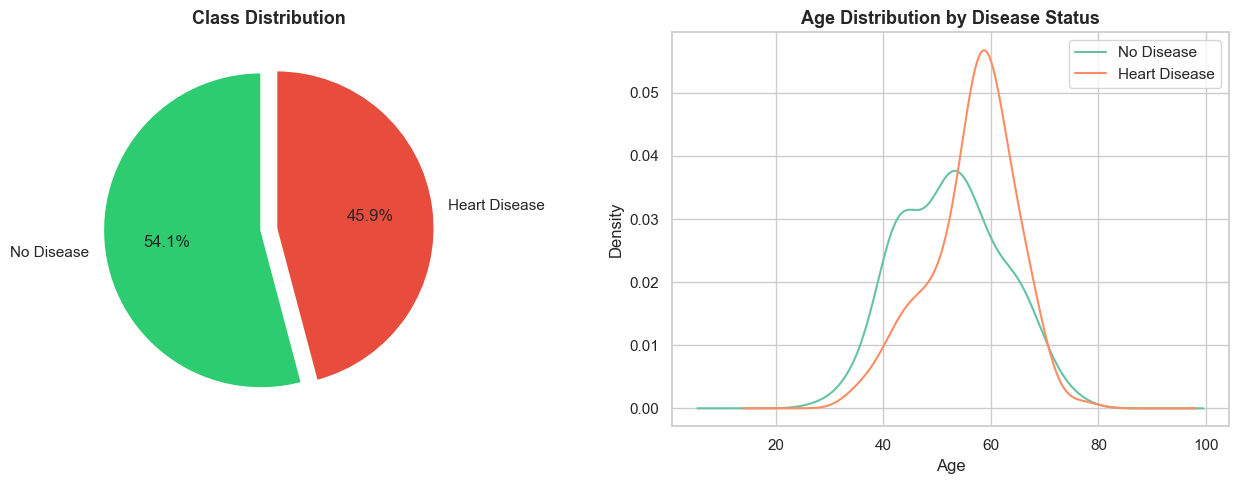

In [4]:
# Rebuild a clean DataFrame for EDA
df_clean = pd.DataFrame(X_clean, columns=FEATURES)
df_clean['target'] = y

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Class balance pie
counts = df_clean['target'].value_counts().sort_index()
axes[0].pie(counts, labels=['No Disease', 'Heart Disease'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0.05, 0.05))
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')

# Age KDE by class
for lbl, grp in df_clean.groupby('target')['age']:
    grp.plot(kind='kde', ax=axes[1], label='No Disease' if lbl == 0 else 'Heart Disease')
axes[1].set_title('Age Distribution by Disease Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.savefig('task3_eda1.png', dpi=150, bbox_inches='tight')
plt.show()

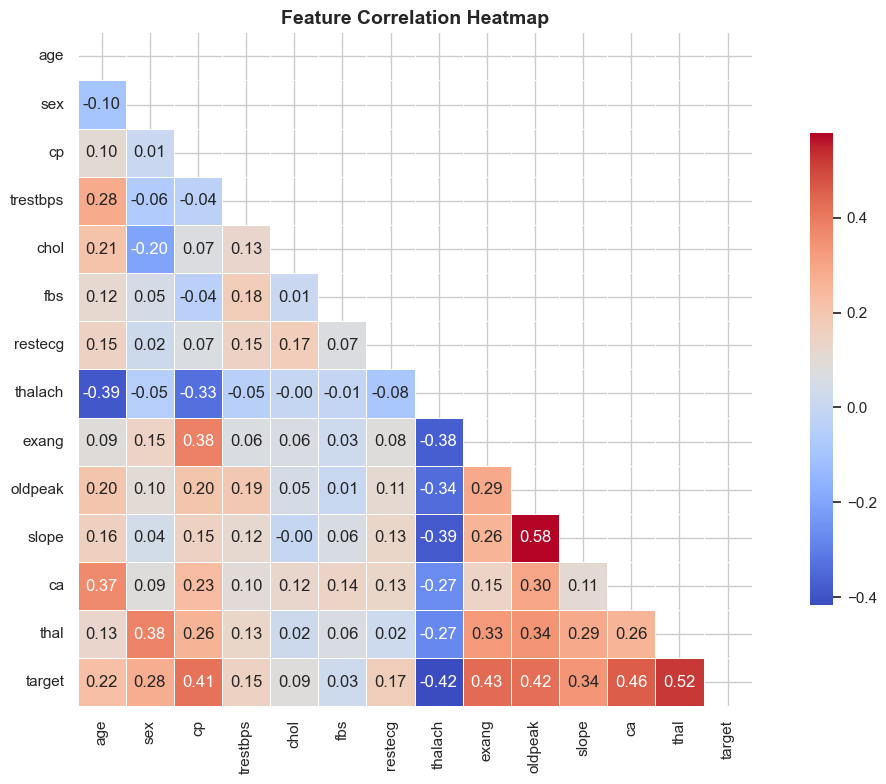

In [5]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_corr.png', dpi=150, bbox_inches='tight')
plt.show()

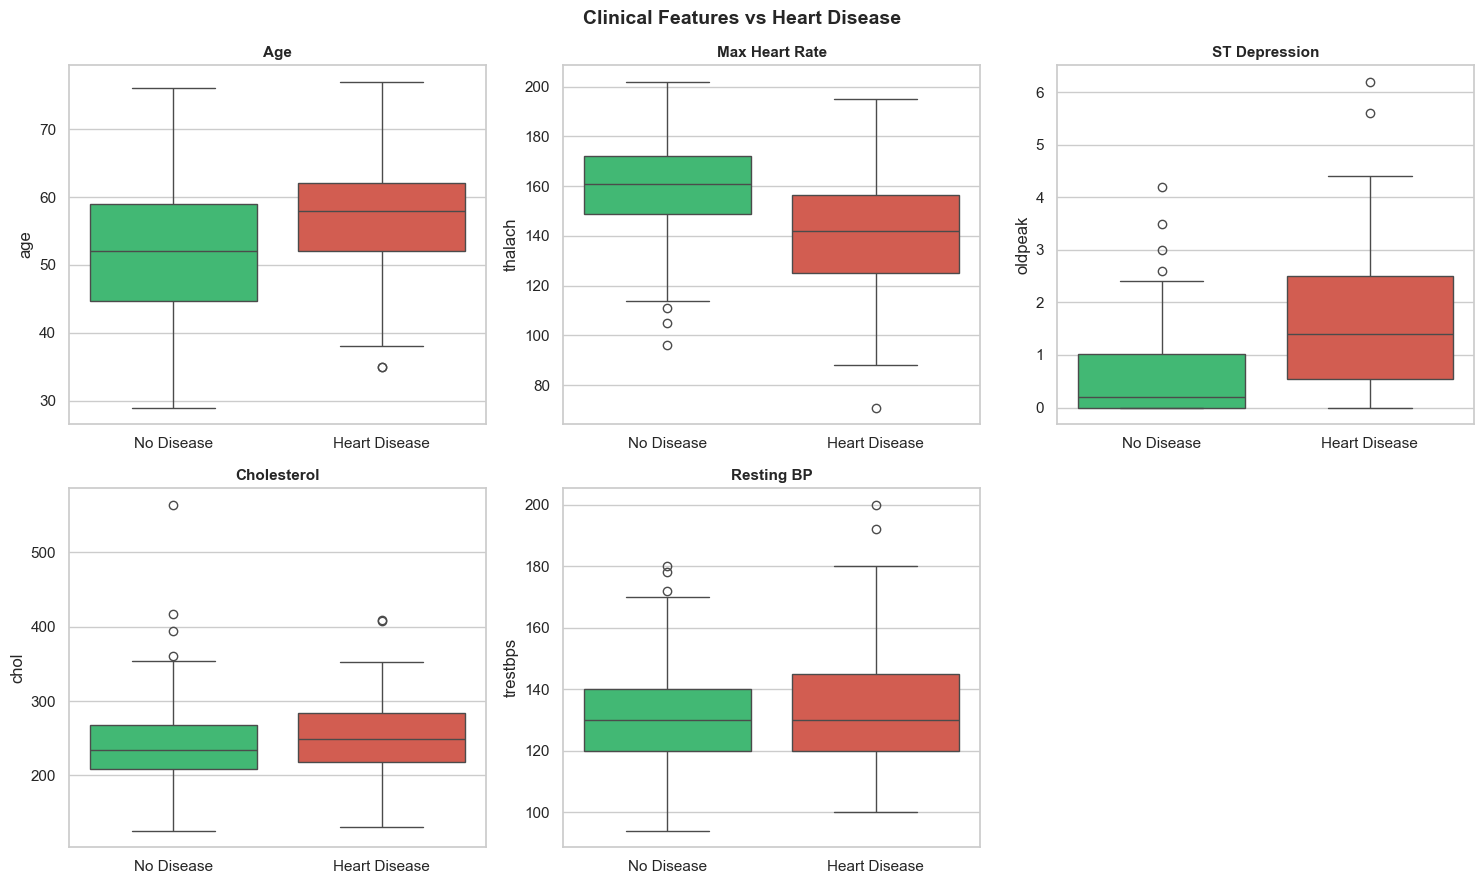

In [6]:
# Box plots — key clinical features vs target
key_features = ['age', 'thalach', 'oldpeak', 'chol', 'trestbps']
key_labels   = ['Age', 'Max Heart Rate', 'ST Depression', 'Cholesterol', 'Resting BP']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(key_features, key_labels)):
    sns.boxplot(data=df_clean, x='target', y=feat,
                palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Disease', 'Heart Disease'])
    axes[i].set_title(f'{label}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

axes[5].axis('off')
plt.suptitle('Clinical Features vs Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_features.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Train/Test Split & Model Training

In [7]:
# Split CLEAN (NaN-free) data
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.20, random_state=42, stratify=y
)

# Hard assertion — this is the bug that caused the original error
assert np.isnan(X_train).sum() == 0, 'BUG: NaNs still in X_train!'
assert np.isnan(X_test).sum()  == 0, 'BUG: NaNs still in X_test!'
print(f'NaN check passed  ✅   Train {X_train.shape}  /  Test {X_test.shape}')

# Scale for Logistic Regression (tree models do NOT need scaling)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ── Logistic Regression ───────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

# ── Decision Tree ─────────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42, min_samples_leaf=5)
dt.fit(X_train, y_train)

print('\nModels trained!')
lr_cv = cross_val_score(lr, X_train_s, y_train, cv=5, scoring='accuracy').mean()
dt_cv = cross_val_score(dt, X_train,   y_train, cv=5, scoring='accuracy').mean()
print(f'  Logistic Regression CV Accuracy : {lr_cv:.3f}')
print(f'  Decision Tree CV Accuracy       : {dt_cv:.3f}')

NaN check passed  ✅   Train (242, 13)  /  Test (61, 13)

Models trained!
  Logistic Regression CV Accuracy : 0.826
  Decision Tree CV Accuracy       : 0.768


## Step 6: Confusion Matrix & Classification Report

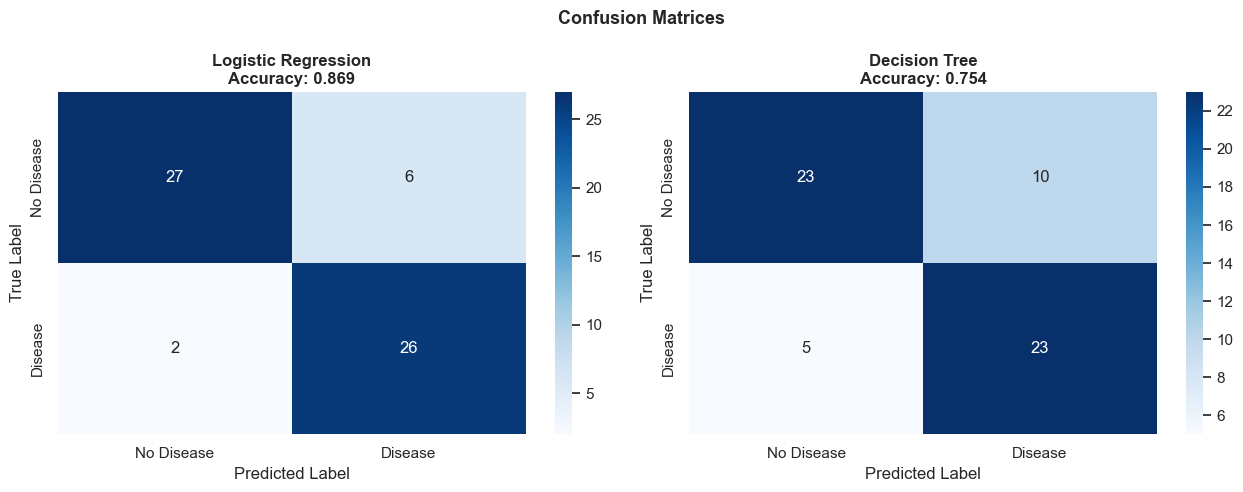


=== Logistic Regression ===
              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


=== Decision Tree ===
              precision    recall  f1-score   support

  No Disease       0.82      0.70      0.75        33
     Disease       0.70      0.82      0.75        28

    accuracy                           0.75        61
   macro avg       0.76      0.76      0.75        61
weighted avg       0.76      0.75      0.75        61



In [8]:
eval_pairs = [
    ('Logistic Regression', lr, X_test_s),
    ('Decision Tree',       dt, X_test),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, model, X_ev) in zip(axes, eval_pairs):
    preds = model.predict(X_ev)
    acc   = accuracy_score(y_test, preds)
    cm    = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    ax.set_title(f'{name}\nAccuracy: {acc:.3f}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

for name, model, X_ev in eval_pairs:
    print(f'\n=== {name} ===')
    print(classification_report(y_test, model.predict(X_ev),
                                target_names=['No Disease', 'Disease']))

## Step 7: ROC Curve

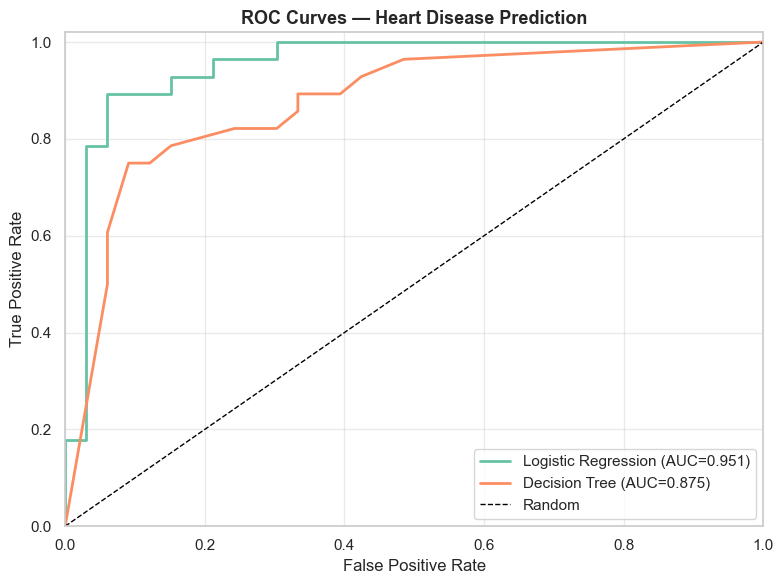

In [9]:
plt.figure(figsize=(8, 6))
for name, model, X_ev in eval_pairs:
    probs = model.predict_proba(X_ev)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc(fpr, tpr):.3f})')

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Heart Disease Prediction', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('task3_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Feature Importance

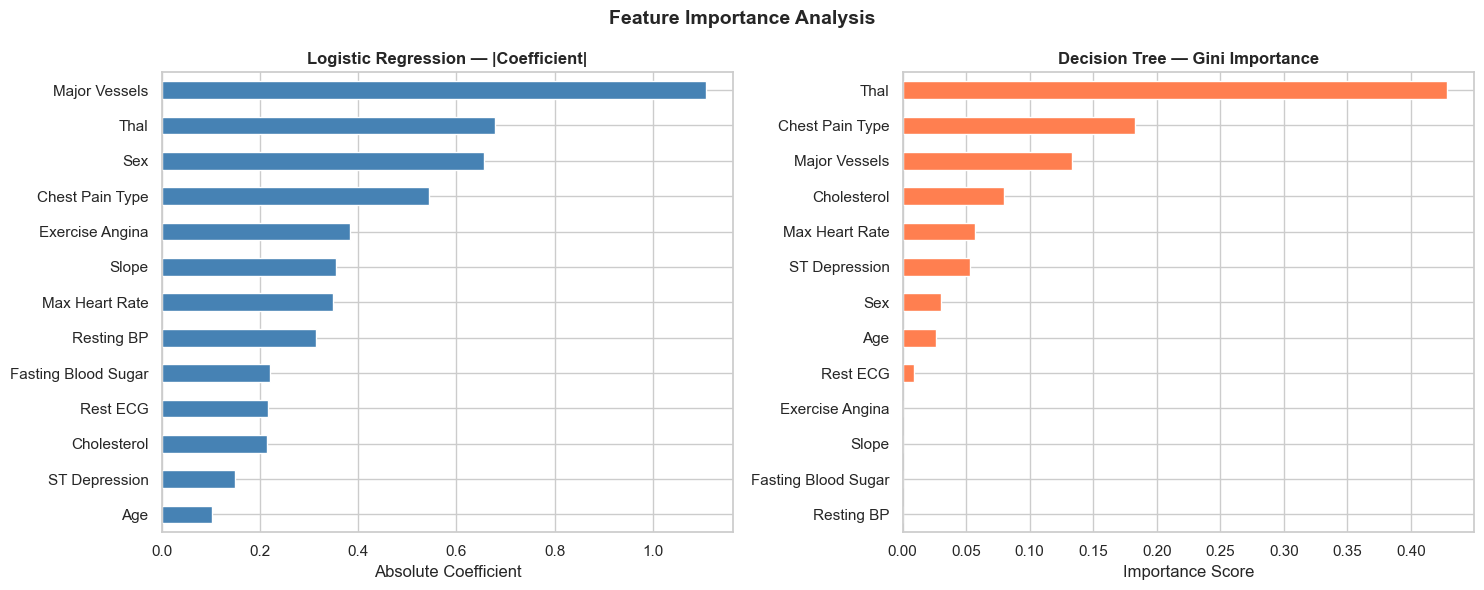

Top 3 features (Decision Tree):
Thal               0.428346
Chest Pain Type    0.183233
Major Vessels      0.133514


In [10]:
FEATURE_LABELS = ['Age','Sex','Chest Pain Type','Resting BP','Cholesterol',
                  'Fasting Blood Sugar','Rest ECG','Max Heart Rate',
                  'Exercise Angina','ST Depression','Slope','Major Vessels','Thal']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

lr_coef = pd.Series(np.abs(lr.coef_[0]), index=FEATURE_LABELS).sort_values(ascending=True)
lr_coef.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Logistic Regression — |Coefficient|', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Absolute Coefficient')

dt_imp = pd.Series(dt.feature_importances_, index=FEATURE_LABELS).sort_values(ascending=True)
dt_imp.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Decision Tree — Gini Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 3 features (Decision Tree):')
print(dt_imp.sort_values(ascending=False).head(3).to_string())

## Step 9: Summary & Key Findings

**Why the original error happened:**
The UCI dataset marks missing values as `?`, which pandas reads as `NaN`.
Using `df['ca'].fillna(..., inplace=True)` on pandas ≥ 2.0 with Copy-on-Write
can silently fail to update the original DataFrame, leaving NaNs that crash sklearn.
The fix is `SimpleImputer.fit_transform()`, which operates on the numpy array directly
and is guaranteed to return a NaN-free result.

**Top Predictive Features:**
1. **Chest Pain Type (cp)** — strongest discriminator
2. **Max Heart Rate (thalach)** — lower HR under stress = higher risk
3. **ST Depression (oldpeak)** — sign of exercise-induced ischemia
4. **Thal / Major Vessels** — structural cardiac indicators

**⚠️ Disclaimer:** Educational use only. Not a medical diagnostic tool.